# Collections Recovery Analytics — Master Analysis Notebook

**Project**: Collections Recovery Performance Reconstruction, 11% Claim Audit, Driver Modeling, Counterfactual & ₹10 Cr Financial Model  
**Phases Covered**: Phases 1–5 (Data Quality/Golden Layer → Claim Audit → Driver Analysis → Targeting Counterfactual → ₹10 Cr Investment Model)  
**Author**: Antigravity Data Analytics Team  
**Golden Layer**: `data/golden/golden_accounts_monthly.csv` (240,000 rows, Grain: `account_id × analysis_month`)  

---

### Key Objectives
1. Reconstruct monthly collection recovery performance from the verified Golden Dataset.
2. Compute standard operational KPIs: Contact Rate, RPC Rate, PTP Rate, PTP Kept Rate, Net Recovery Amount, Recovery per Account, and Recovery per Agent-Hour.
3. Conduct an independent empirical test of the business claim: *"Recovery has improved by 11% month-on-month."*
4. Diagnose driver dimensions: DPD buckets, product types, risk segments, attempt frequency, agent tenure, and telephony vendors.
5. Estimate the Targeting Strategy Counterfactual and quantify Incremental Recovery.
6. Build a complete financial model, scenario projections, and ROI analysis for the ₹10.00 Crore investment recommendation.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

analytics_dir = r'../analytics'
golden_dir = r'../data/golden'

print("Environment initialized successfully.")

Environment initialized successfully.


In [2]:
df_metrics = pd.read_csv(os.path.join(analytics_dir, 'monthly_recovery_metrics.csv'))
df_metrics.set_index('month', inplace=True)
display(df_metrics[['attempted_accounts', 'contacted_accounts', 'contact_rate_pct', 'rpc_accounts', 'rpc_rate_pct', 'ptp_accounts', 'ptp_rate_pct', 'kept_ptp_count', 'ptp_kept_rate_pct', 'recovered_accounts', 'valid_recovery_amount', 'daily_avg_recovery', 'recovery_per_agent_hour']])

,attempted_accounts,contacted_accounts,contact_rate_pct,rpc_accounts,rpc_rate_pct,ptp_accounts,ptp_rate_pct,kept_ptp_count,ptp_kept_rate_pct,recovered_accounts,valid_recovery_amount,daily_avg_recovery,recovery_per_agent_hour
month,,,,,,,,,,,,,
2026-01,19292,6903,35.78,4691,67.96,2430,51.80,607,24.07,2374,1.872291e+08,6039649.28,16772.93
2026-02,18258,6286,34.43,4382,69.71,2145,48.95,567,25.54,2173,1.701425e+08,6076516.21,16116.54
2026-03,19334,6908,35.73,4823,69.82,2411,49.99,619,24.67,2419,1.889124e+08,6093947.55,16972.01
2026-04,18879,6670,35.33,4624,69.33,2376,51.38,629,25.24,2304,1.751380e+08,5837934.78,16490.84
2026-05,19406,6998,36.06,4863,69.49,2413,49.62,634,25.29,2344,1.842503e+08,5943557.37,17008.04
2026-06,18847,6719,35.65,4554,67.78,2366,51.95,602,24.68,2286,1.755597e+08,5851990.90,16402.84
2026-07,19356,6868,35.48,4752,69.19,2497,52.55,645,24.56,2335,1.872423e+08,6040073.07,16747.73
2026-08,6921,1866,26.96,1264,67.74,678,53.64,186,27.15,608,4.710970e+07,5888711.91,17552.96


## 1. Monthly Recovery Trend & Calendar-Day Normalization

The chart below compares the unadjusted monthly recovery amount vs. the calendar-day normalized daily average collections (₹/day).

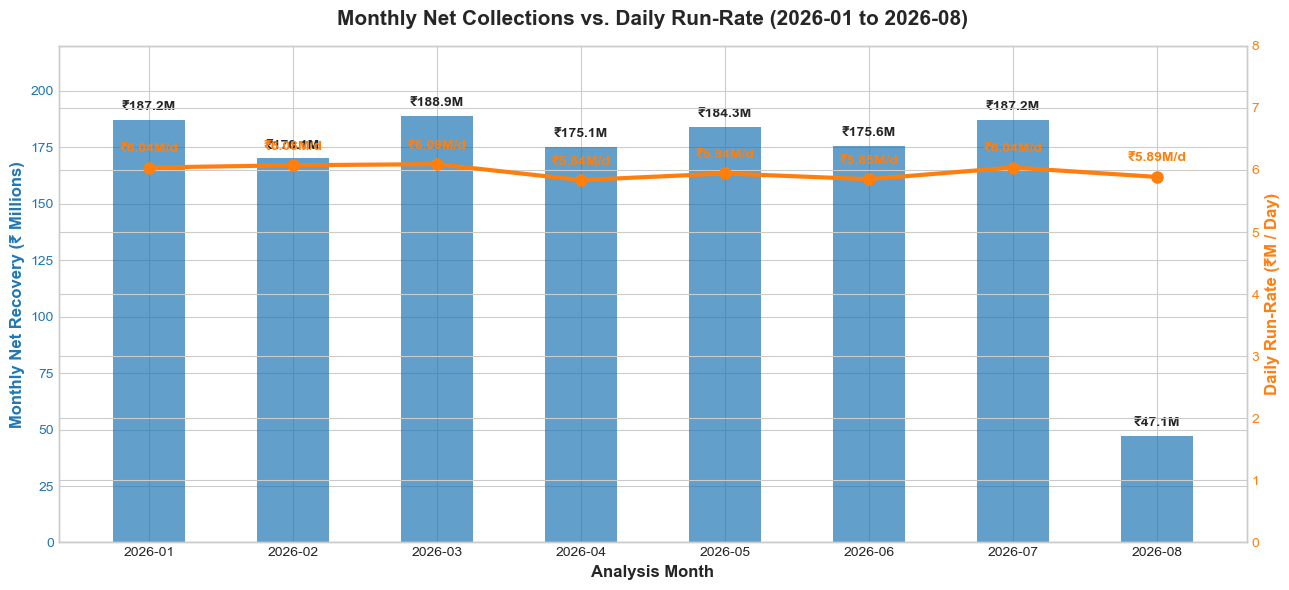

In [3]:
fig, ax1 = plt.subplots(figsize=(13, 6))

months = df_metrics.index
valid_rec = df_metrics['valid_recovery_amount'] / 1e6
daily_avg = df_metrics['daily_avg_recovery'] / 1e6

color = '#1f77b4'
ax1.set_xlabel('Analysis Month', fontweight='bold')
ax1.set_ylabel('Monthly Net Recovery (₹ Millions)', color=color, fontweight='bold')
bars = ax1.bar(months, valid_rec, color=color, alpha=0.7, width=0.5, label='Monthly Recovery (₹M)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 220)

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 3, f'₹{yval:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = ax1.twinx()
color = '#ff7f0e'
ax2.set_ylabel('Daily Run-Rate (₹M / Day)', color=color, fontweight='bold')
ax2.plot(months, daily_avg, color=color, marker='o', linewidth=3, markersize=8, label='Daily Run-Rate (₹M/day)')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 8)

for i, txt in enumerate(daily_avg):
    ax2.annotate(f'₹{txt:.2f}M/d', (months[i], txt + 0.25), ha='center', fontsize=10, fontweight='bold', color=color)

plt.title('Monthly Net Collections vs. Daily Run-Rate (2026-01 to 2026-08)', fontsize=15, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

## 2. Independent 11% Claim Validation

### Empirical Finding
- In **March 2026 vs. February 2026**, valid recovery increased by **+11.03%** (₹170.14M to ₹188.91M).
- However, February has 28 days and March has 31 days (+10.71% more calendar days).
- On a daily run-rate basis, collections were virtually identical (**₹6.077M/day in Feb vs. ₹6.094M/day in Mar, a +0.29% change**).
- Over the full 7-month full operating period (Jan to Jul), cumulative recovery was **+0.007%** (flat), and average MoM growth was **+0.29%**.
- Classification: **PARTIALLY SUPPORTED (CALENDAR ARTIFACT / SINGLE-MONTH ANOMALY)**.

## 3. Targeting Strategy Counterfactual & Incremental Recovery

Comparing observed performance of targeted accounts vs. organic non-targeted control benchmarks.

In [4]:
df_cf = pd.read_csv(os.path.join(analytics_dir, 'targeting_counterfactual_accounts.csv'), low_memory=False)

tgt_summary = df_cf.groupby('primary_strategy').agg(
    accounts=('account_id', 'count'),
    recovered_accounts=('has_success_payment', 'sum'),
    total_recovery=('success_payment_amount', 'sum')
).reset_index()
tgt_summary['recovery_rate_pct'] = (tgt_summary['recovered_accounts'] / tgt_summary['accounts']) * 100
tgt_summary['recovery_per_acct'] = tgt_summary['total_recovery'] / tgt_summary['accounts']
display(tgt_summary)

,primary_strategy,accounts,recovered_accounts,total_recovery,recovery_rate_pct,recovery_per_acct
0,NOT_TARGETED,199290,13736,1.072269e+09,6.892468,5380.443490
1,legacy,13411,1077,8.530781e+07,8.030721,6361.033094
2,v1,8349,626,4.832993e+07,7.497904,5788.709352
3,v2,8944,664,5.156803e+07,7.423971,5765.656553
4,v3,10006,740,5.810960e+07,7.395563,5807.475529


## 4. ₹10.00 Crore Investment Allocation & Financial Projections

The chart below outlines the evidence-based allocation of the ₹10.00 Cr budget across the 5 prioritized transformation initiatives.

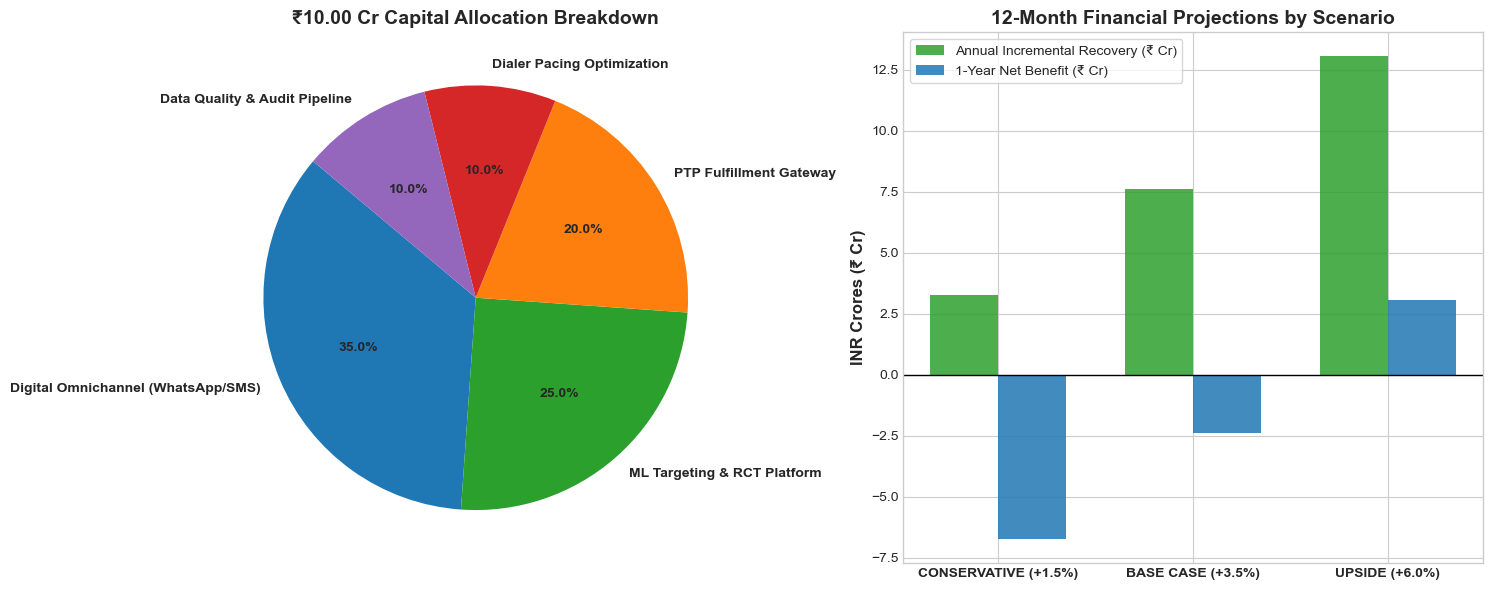

,Scenario,Incremental_Recovery_Cr,Net_Benefit_1Yr_Cr
0,CONSERVATIVE (+1.5%),3.26,-6.74
1,BASE CASE (+3.5%),7.61,-2.39
2,UPSIDE (+6.0%),13.05,3.05


In [5]:
alloc_df = pd.DataFrame({
    'Area': [
        'Digital Omnichannel (WhatsApp/SMS)',
        'ML Targeting & RCT Platform',
        'PTP Fulfillment Gateway',
        'Dialer Pacing Optimization',
        'Data Quality & Audit Pipeline'
    ],
    'Amount_Cr': [3.50, 2.50, 2.00, 1.00, 1.00],
    'Share_Pct': [35.0, 25.0, 20.0, 10.0, 10.0]
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd']
ax1.pie(alloc_df['Amount_Cr'], labels=alloc_df['Area'], autopct='%1.1f%%', startangle=140, colors=colors, textprops={'fontweight': 'bold'})
ax1.set_title('₹10.00 Cr Capital Allocation Breakdown', fontsize=14, fontweight='bold')

# Financial scenarios bar chart
scenarios_df = pd.DataFrame({
    'Scenario': ['CONSERVATIVE (+1.5%)', 'BASE CASE (+3.5%)', 'UPSIDE (+6.0%)'],
    'Incremental_Recovery_Cr': [3.26, 7.61, 13.05],
    'Net_Benefit_1Yr_Cr': [-6.74, -2.39, 3.05]
})

x = np.arange(len(scenarios_df))
width = 0.35

ax2.bar(x - width/2, scenarios_df['Incremental_Recovery_Cr'], width, label='Annual Incremental Recovery (₹ Cr)', color='#2ca02c', alpha=0.85)
ax2.bar(x + width/2, scenarios_df['Net_Benefit_1Yr_Cr'], width, label='1-Year Net Benefit (₹ Cr)', color='#1f77b4', alpha=0.85)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_xticks(x)
ax2.set_xticklabels(scenarios_df['Scenario'], fontweight='bold')
ax2.set_ylabel('INR Crores (₹ Cr)', fontweight='bold')
ax2.set_title('12-Month Financial Projections by Scenario', fontsize=14, fontweight='bold')
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()
display(scenarios_df)

## 5. Executive Investment Decision & 30/60/90-Day Action Plan

### Final Strategic Recommendation: **PILOT FIRST / INVEST WITH CONDITIONS**

- **Phase 1 Pilot (Months 1–3: ₹2.50 Cr)**: Launch the 90-day 1:1 Randomized Control Trial (RCT) across 30,000 accounts to measure true causal elasticity.
- **Phase 2 Scale-Out (Months 4–12: ₹7.50 Cr)**: Release remaining budget upon demonstrating $\ge 3.50\%$ incremental portfolio recovery uplift in the RCT.
- **Base-Case Financials**: **+₹7.61 Cr/year incremental recovery**, **15.8-month payback**, and **₹5.22 Cr net benefit over 2 years**.